<font color='red'><b>**WARNING**</b></font> <br/>
어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다. <br/>

<div style="text-align: right; color: #7f8c8d; font-size: 0.9em; margin-top: 20px;">
📝 Author: 박사홍 (Sahong Pak)</br>
📧 Contact: sahong.pak@gmail.com</br>
📌 Version: v2.0</br>
📅 Last Updated: 2026-03-12</br>
</div>

</br>

In [1]:
# TODO 0: 실습을 위해 아래 패키지를 import 해주세요.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

wine_dataset = load_wine()
wine_dataframe = pd.DataFrame(wine_dataset.data, columns=wine_dataset.feature_names)
wine_dataframe["quality"] = wine_dataset.target

</br>

# 학습 내용
>이번 장에서는 <strong>이상치와 결측치 처리(Outlier & Missing Value Handling)</strong>에 대해 학습합니다.</br></br>
>데이터 품질을 높이기 위한 이상치 탐지와 결측치 대체 기법을 학습해봅시다.

</br>

# 결측치 처리 (Missing Values)
> 결측치는 데이터에서 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">값이 누락된 항목</mark>으로, 분석과 모델 학습에 영향을 줍니다.

</br>

## 결측치 확인

In [44]:
# TODO 1: 실습용 결측치를 추가합니다.
np.random.seed(42) # 시드 고정: 매번 동일한 인덱스가 선택되도록 함. 하지 않으면 random.choice의 결과가 매번 달라짐
missing_index = np.random.choice(wine_dataframe.index, size=3, replace=False)
wine_dataframe.loc[missing_index, 'proline'] = np.nan
print(f"--- [TODO 1] 결측치가 할당된 인덱스: {missing_index} ---")

--- [TODO 1] 결측치가 할당된 인덱스: [ 19  45 140] ---


In [45]:
# TODO 2: missing_count에 컬럼별 결측치 수를 저장해봅시다.
missing_count = wine_dataframe.isna().sum()

In [48]:
# TODO 3:
#  - total_missing에 전체 결측치 개수를 저정해봅시다.
#  - missing_ratio에 컬럼별 결측 비율(%)을 출력해봅시다.
total_missing = missing_count.sum()
missing_ratio = wine_dataframe.isna().mean() * 100
print(f"--- 전체 결측치 개수: {total_missing}개 ---")
print("--- 컬럼별 결측 비율(%) (0이 아닌 것만 출력) ---")
print(missing_ratio[missing_ratio > 0])

--- 전체 결측치 개수: 3개 ---
--- 컬럼별 결측 비율(%) (0이 아닌 것만 출력) ---
proline    1.685393
dtype: float64


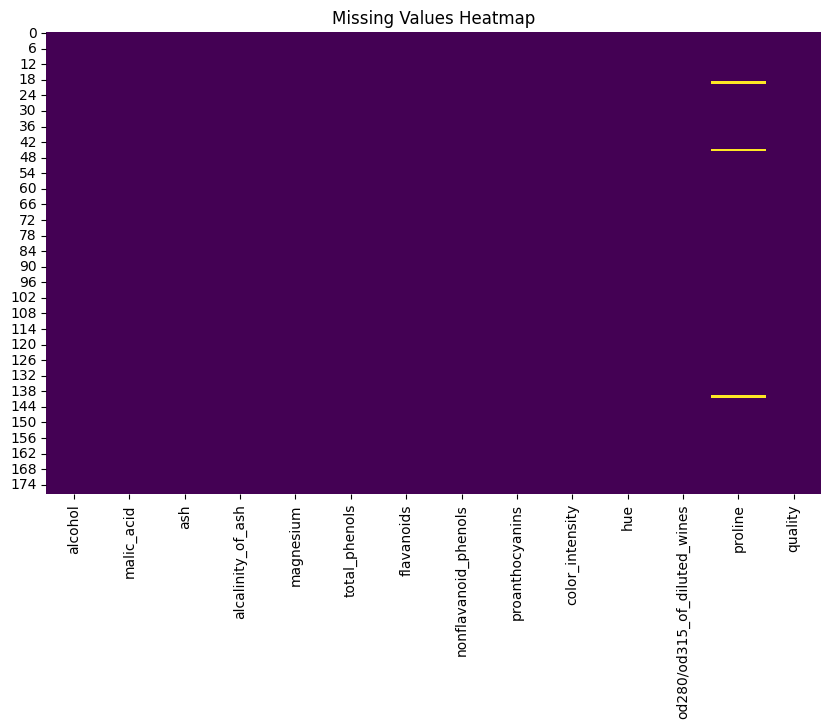

In [51]:
# TODO 4: 히트맵으로 결측치를 확인해봅시다.
plt.figure(figsize=(10, 6))
sns.heatmap(wine_dataframe.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

</br>

## 결측치 처리 방법

<table style="width:100%">
  <thead>
    <tr>
      <th style="text-align:center">방법</th>
      <th style="text-align:center">메서드</th>
      <th style="text-align:center">적합한 상황</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="text-align:center">행 삭제</td><td style="text-align:center"><code>df.dropna()</code></td><td style="text-align:center">결측 비율이 매우 낮을 때</td></tr>
    <tr><td style="text-align:center">열 삭제</td><td style="text-align:center"><code>df.drop(col, axis=1)</code></td><td style="text-align:center">결측 비율이 매우 높을 때</td></tr>
    <tr><td style="text-align:center">평균 대체</td><td style="text-align:center"><code>df.fillna(df.mean())</code></td><td style="text-align:center">수치형, 정규분포</td></tr>
    <tr><td style="text-align:center">중앙값 대체</td><td style="text-align:center"><code>df.fillna(df.median())</code></td><td style="text-align:center">수치형, 이상치 존재</td></tr>
    <tr><td style="text-align:center">최빈값 대체</td><td style="text-align:center"><code>df.fillna(df.mode()[0])</code></td><td style="text-align:center">범주형 데이터</td></tr>
  </tbody>
</table>

In [83]:
# TODO 5: color_intensity_median에 "color_intensity"의 중앙값을 저장해봅시다.
color_intensity_median = wine_dataframe['color_intensity'].median()

In [82]:
# TODO 6:
#  - proline의 결측치를 중앙값으로 대체해봅시다.
#  - 이후 proline에 결측치가 있는지 확인해봅시다.
proline_median = wine_dataframe['proline'].median()
wine_dataframe['proline'] = wine_dataframe['proline'].fillna(proline_median)
print("--- proline 결측치 대체 후 확인 ---")
print(f"proline 결측치 개수: {wine_dataframe['proline'].isna().sum()}")

--- proline 결측치 대체 후 확인 ---
proline 결측치 개수: 0


In [81]:
# TODO 7: flavanoids_mean에 "flavanoids"의 평균값으로 대체해봅시다.
flavanoids_mean = wine_dataframe['flavanoids'].mean()
wine_dataframe['flavanoids'] = wine_dataframe['flavanoids'].fillna(flavanoids_mean)

In [80]:
# TODO 8: 모든 결측치가 처리되었는지 확인해봅시다.
print("--- 전체 데이터프레임 결측치 최종 점검 ---")
print(f"남아있는 총 결측치 개수: {wine_dataframe.isna().sum().sum()}")

--- 전체 데이터프레임 결측치 최종 점검 ---
남아있는 총 결측치 개수: 0


💡결측치 처리 순서
> 타겟(라벨)에 결측치가 있으면 해당 행을 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">먼저 삭제</mark>한 후, 피처의 결측치를 처리합니다.

</br>

# 이상치 탐지 (Outlier Detection)
> 이상치는 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">다른 데이터와 크게 벗어난 값</mark>으로, 모델 성능에 부정적 영향을 줄 수 있습니다.

</br>

## IQR 방법 (Interquartile Range)
> 사분위수를 기반으로 이상치 범위를 정의하는 통계적 방법입니다.

<div style="text-align:center">

</div>

In [59]:
# TODO 9: "malic_acid"의 Q1, Q3를 각각 malic_acid_q1, malic_acid_q3에 저장해봅시다.
malic_acid_q1 = wine_dataframe['malic_acid'].quantile(0.25)
malic_acid_q3 = wine_dataframe['malic_acid'].quantile(0.75)

In [31]:
# TODO 10:
#  - malic_acid_iqr에 IQR를 계산하여 저장해봅시다.
IQR = malic_acid_q3 - malic_acid_q1
#  - lower_bound에 하한을 저장해봅시다.
lower_bound = malic_acid_q1 - 1.5 * IQR
#  - upper_bound에 상한을 저장해봅시다.
upper_bound = malic_acid_q3 + 1.5 * IQR

In [61]:
# TODO 11: 경계를 벗어난 이상치를 malic_acid_outliers에 저장해봅시다.
malic_acid_outliers = wine_dataframe[(wine_dataframe['malic_acid'] < lower_bound) | 
                                     (wine_dataframe['malic_acid'] > upper_bound)]

print("--- 탐지된 malic_acid 이상치 데이터 ---")
malic_acid_outliers[['malic_acid']]

--- 탐지된 malic_acid 이상치 데이터 ---


,malic_acid
123,5.80
137,5.51
173,5.65


</br>

## 박스플롯 시각화

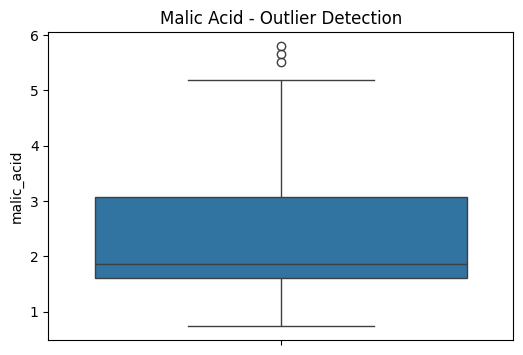

In [69]:
# TODO 12: "malic_acid" 컬럼을 박스플롯으로 확인해봅시다.
plt.figure(figsize=(6, 4))
sns.boxplot(data=wine_dataframe, y="malic_acid")
plt.title("Malic Acid - Outlier Detection")
plt.show()

💡박스플롯 읽는 법
> 상자: Q1~Q3 (데이터의 50%), 중앙선: 중앙값</br>
> 수염: `Q1 - 1.5*IQR` ~ `Q3 + 1.5*IQR`, 수염 밖의 점: <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">이상치</mark>

</br>

## 이상치 처리

In [70]:
# TODO 13: wine_dataframe_clean에 이상치를 제거한 데이터프레임을 만들어봅시다.
# drop()에 이상치의 인덱스를 전달하여 해당 행들을 통째로 삭제합니다.
wine_dataframe_clean = wine_dataframe.drop(index=malic_acid_outliers.index)

In [74]:
# TODO 14: 이상치가 제거되었는지 검증해봅시다.
print("--- 이상치 제거 전후 데이터 크기 비교 ---")
print(f"제거 전: {wine_dataframe.shape}")
print(f"제거 후: {wine_dataframe_clean.shape}")

--- 이상치 제거 전후 데이터 크기 비교 ---
제거 전: (178, 14)
제거 후: (175, 14)


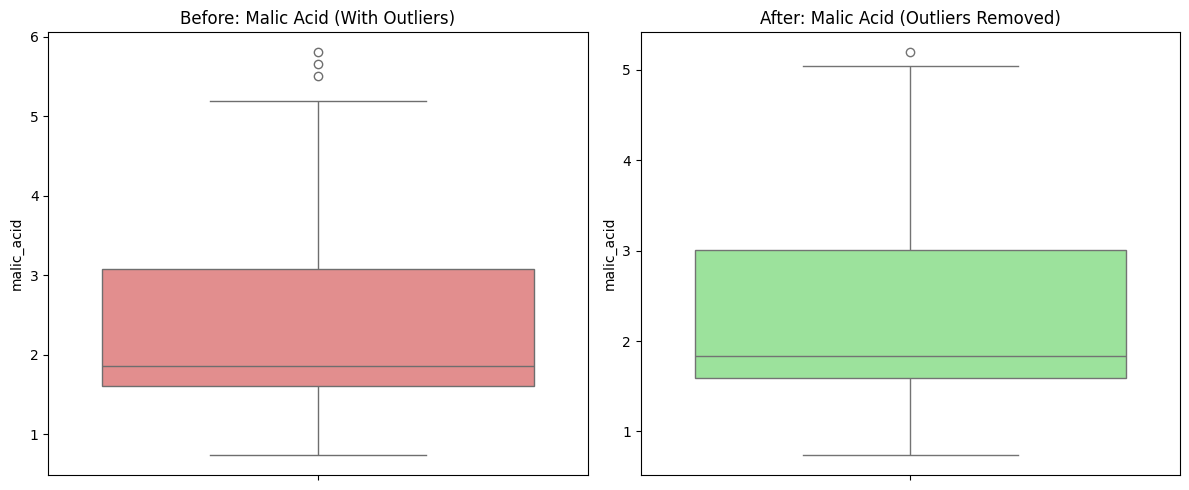

In [79]:
# TODO 15: 이상치 제거 전후를 박스플롯으로 비교해봅시다.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 제거 전 (Before)
sns.boxplot(data=wine_dataframe, y="malic_acid", ax=axes[0], color="lightcoral")
axes[0].set_title("Before: Malic Acid (With Outliers)")

# 제거 후 (After)
sns.boxplot(data=wine_dataframe_clean, y="malic_acid", ax=axes[1], color="lightgreen")
axes[1].set_title("After: Malic Acid (Outliers Removed)")

plt.tight_layout()
plt.show()

💡이상치를 항상 제거해야 할까?
> 아닙니다. 이상치가 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">실제 의미 있는 데이터</mark>일 수 있습니다.</br>
> 도메인 지식을 바탕으로 제거/보정 여부를 판단해야 합니다.

💡이상치를 제거했는데 또 이상치가 보인다?
> 이상치를 제거한 후 박스플롯을 다시 그리면, 새로운 이상치가 나타날 수 있습니다.</br>
> 이는 버그가 아니라 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">IQR이 현재 데이터 기준으로 재계산</mark>되기 때문입니다.</br></br>
> **원리**: 극단값을 제거하면 Q1, Q3, IQR이 모두 달라지고, 경계가 더 좁아집니다.</br>
> 이전에는 정상 범위 안에 있던 값이 새로운 (더 좁은) 경계를 넘어 이상치로 표시됩니다.</br></br>
> 따라서 IQR 기반 이상치 제거를 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">반복 적용하면 데이터가 계속 줄어들 수 있으므로</mark>, 보통 **1회만 적용**하거나 도메인 지식을 기반으로 판단합니다.